# Home task: decision trees

### Load dataset and prepare data


In [135]:
# load dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

# take data and labels
X = cancer.data
y = cancer.target
labels = cancer.target_names
features = cancer.feature_names

print('labels:', labels)
print('features:', features)

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### Decision Tree model


In [136]:
# import model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz

# create and train model
clf = DecisionTreeClassifier(max_depth=3, random_state=0)
clf.fit(X_train, y_train)

# check accuracy
print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

# visualize tree
graph_viz = tree.export_graphviz(
    clf,
    out_file=None,
    feature_names=features,
    class_names=labels,
    filled=True
)

graph = graphviz.Source(graph_viz)
graph.view(cleanup=True)

train accuracy= 97.653%
test accuracy= 93.706%


'Source.gv.pdf'

### Random Forest model


In [137]:
# import model
from sklearn.ensemble import RandomForestClassifier

# create and train model
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)

# check accuracy
print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


### Gradient Boosting model


In [138]:
# import model
from sklearn.ensemble import GradientBoostingClassifier

# create and train model
clf = GradientBoostingClassifier(random_state=0)
clf.fit(X_train, y_train)

# check accuracy
print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


### XGBoost model


In [139]:
# import model
from xgboost import XGBClassifier

# create and train model
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

# check accuracy
print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


## Additional tasks

## 1) Binary Classification



In this task, I predict whether a person earns more than 50K per year.
I use the Adult census dataset and XGBoost classifier.

Load classification dataset

In [140]:
# load dataset
from sklearn.datasets import fetch_openml
import pandas as pd

data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame

# show first rows
df_income.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,18.0,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K


### Data preprocessing

In [141]:
# separate features and target
X_income = df_income.drop('class', axis=1)
y_income = df_income['class']

# fill missing values
for col in X_income.columns:
    if str(X_income[col].dtype) == 'category' or X_income[col].dtype == 'object':
        X_income[col] = X_income[col].astype('object').fillna('missing')
    else:
        X_income[col] = X_income[col].fillna(X_income[col].median())

# encode categorical features
X_income = pd.get_dummies(X_income)

# encode target
y_income = (y_income == '>50K').astype(int)

print(X_income.shape)
print(y_income.shape)

(48842, 108)
(48842,)


### Correlation heatmap

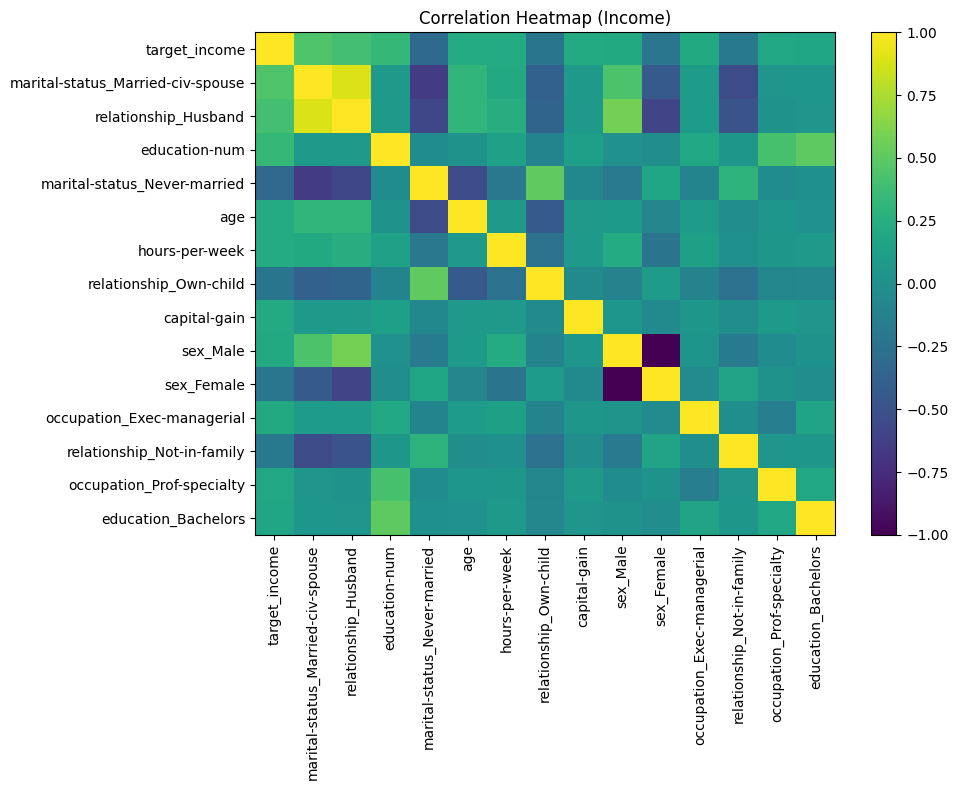

In [142]:
import matplotlib.pyplot as plt

# add target for correlation analysis
income_corr_df = X_income.copy()
income_corr_df['target_income'] = y_income

# take features with strongest correlation to target
top_income_corr = income_corr_df.corr()['target_income'].abs().sort_values(ascending=False).head(15).index

# build smaller correlation matrix
income_corr_matrix = income_corr_df[top_income_corr].corr()

# plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(income_corr_matrix, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(income_corr_matrix.columns)), income_corr_matrix.columns, rotation=90)
plt.yticks(range(len(income_corr_matrix.index)), income_corr_matrix.index)
plt.title("Correlation Heatmap (Income)")
plt.tight_layout()
plt.show()

### Train XGBoost Classifier

In [143]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# split data
X_income_train, X_income_test, y_income_train, y_income_test = train_test_split(
    X_income, y_income, test_size=0.25, random_state=0, stratify=y_income
)

# create model
clf_income = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=0
)

# train model
clf_income.fit(X_income_train, y_income_train)

# evaluate
print("train accuracy= {:.3%}".format(clf_income.score(X_income_train, y_income_train)))
print("test accuracy= {:.3%}".format(clf_income.score(X_income_test, y_income_test)))

train accuracy= 89.935%
test accuracy= 86.987%


### Classification metrics

In [144]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# make predictions
y_income_pred = clf_income.predict(X_income_test)

# calculate metrics
print("Accuracy = {:.3f}".format(accuracy_score(y_income_test, y_income_pred)))
print("Precision = {:.3f}".format(precision_score(y_income_test, y_income_pred)))
print("Recall = {:.3f}".format(recall_score(y_income_test, y_income_pred)))
print("F1-score = {:.3f}".format(f1_score(y_income_test, y_income_pred)))

# confusion matrix
cm_income = confusion_matrix(y_income_test, y_income_pred)
print("\nConfusion matrix:")
print(cm_income)

Accuracy = 0.870
Precision = 0.772
Recall = 0.647
F1-score = 0.704

Confusion matrix:
[[8732  557]
 [1032 1890]]


### Feature importance


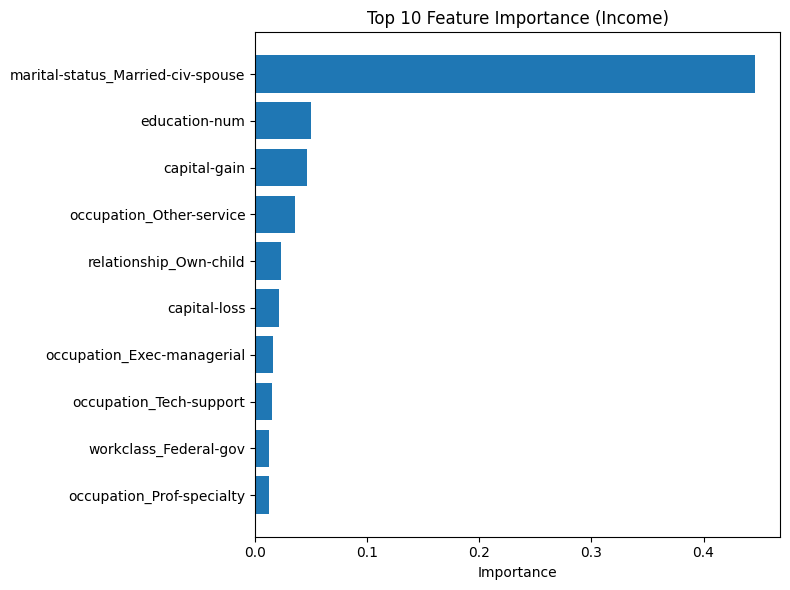

In [145]:
# get feature importance
income_importance = pd.Series(clf_income.feature_importances_, index=X_income.columns)
income_importance = income_importance.sort_values(ascending=False).head(10)

# plot
plt.figure(figsize=(8, 6))
plt.barh(income_importance.index[::-1], income_importance.values[::-1])
plt.title("Top 10 Feature Importance (Income)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 2) Regression

In this task, I predict house prices with XGBoost regressor.

Load regression dataset

In [146]:
# load dataset
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame

# show first rows
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1.0,60.0,RL,65.0,8450.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,2.0,2008.0,WD,Normal,208500.0
1,2.0,20.0,RL,80.0,9600.0,Pave,None,Reg,Lvl,AllPub,...,0.0,None,None,None,0.0,5.0,2007.0,WD,Normal,181500.0
2,3.0,60.0,RL,68.0,11250.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,9.0,2008.0,WD,Normal,223500.0
3,4.0,70.0,RL,60.0,9550.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,2.0,2006.0,WD,Abnorml,140000.0
4,5.0,60.0,RL,84.0,14260.0,Pave,None,IR1,Lvl,AllPub,...,0.0,None,None,None,0.0,12.0,2008.0,WD,Normal,250000.0


### Data preprocessing

In [147]:
# separate features and target
X_house = df_house.drop('SalePrice', axis=1)
y_house = df_house['SalePrice']

# fill missing values
for col in X_house.columns:
    if str(X_house[col].dtype) == 'category' or X_house[col].dtype == 'object':
        X_house[col] = X_house[col].astype('object').fillna('missing')
    else:
        X_house[col] = X_house[col].fillna(X_house[col].median())

# encode categorical features
X_house = pd.get_dummies(X_house)

print(X_house.shape)
print(y_house.shape)

(1460, 305)
(1460,)


### Correlation heatmap

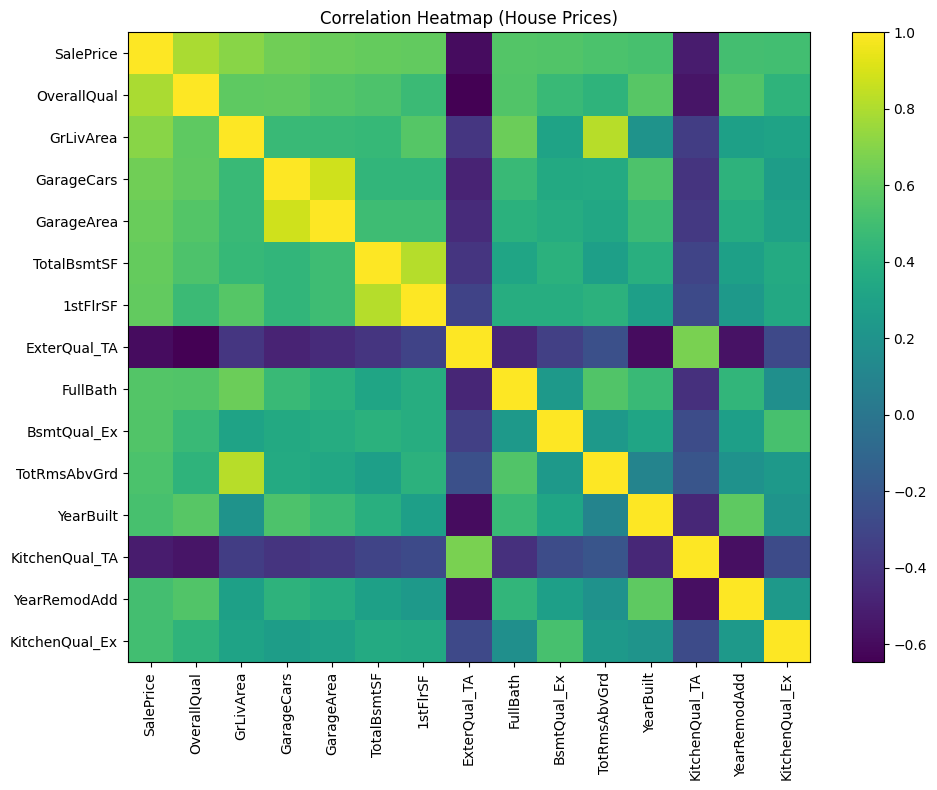

In [148]:
# add target for correlation analysis
house_corr_df = X_house.copy()
house_corr_df['SalePrice'] = y_house

# take features with strongest correlation to target
top_house_corr = house_corr_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(15).index

# build smaller correlation matrix
house_corr_matrix = house_corr_df[top_house_corr].corr()

# plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(house_corr_matrix, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(house_corr_matrix.columns)), house_corr_matrix.columns, rotation=90)
plt.yticks(range(len(house_corr_matrix.index)), house_corr_matrix.index)
plt.title("Correlation Heatmap (House Prices)")
plt.tight_layout()
plt.show()

### Train XGBoost Regressor

In [149]:
from xgboost import XGBRegressor

# split data
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size=0.25, random_state=0
)

# create model
reg_house = XGBRegressor(random_state=0)

# train model
reg_house.fit(X_house_train, y_house_train)

# evaluate
print("train score (R^2)= {:.3f}".format(reg_house.score(X_house_train, y_house_train)))
print("test score (R^2)= {:.3f}".format(reg_house.score(X_house_test, y_house_test)))

train score (R^2)= 1.000
test score (R^2)= 0.843


### Regression metrics

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# make predictions
y_house_pred = reg_house.predict(X_house_test)

# calculate metrics
mae_house = mean_absolute_error(y_house_test, y_house_pred)
mse_house = mean_squared_error(y_house_test, y_house_pred)
rmse_house = mean_squared_error(y_house_test, y_house_pred, squared=False)
r2_house = r2_score(y_house_test, y_house_pred)

print("MAE = {:.3f}".format(mae_house))
print("MSE = {:.3f}".format(mse_house))
print("RMSE = {:.3f}".format(rmse_house))
print("R^2 = {:.3f}".format(r2_house))

MAE = 16885.119
MSE = 1035540927.206
RMSE = 32179.822
R^2 = 0.843


### Feature importance

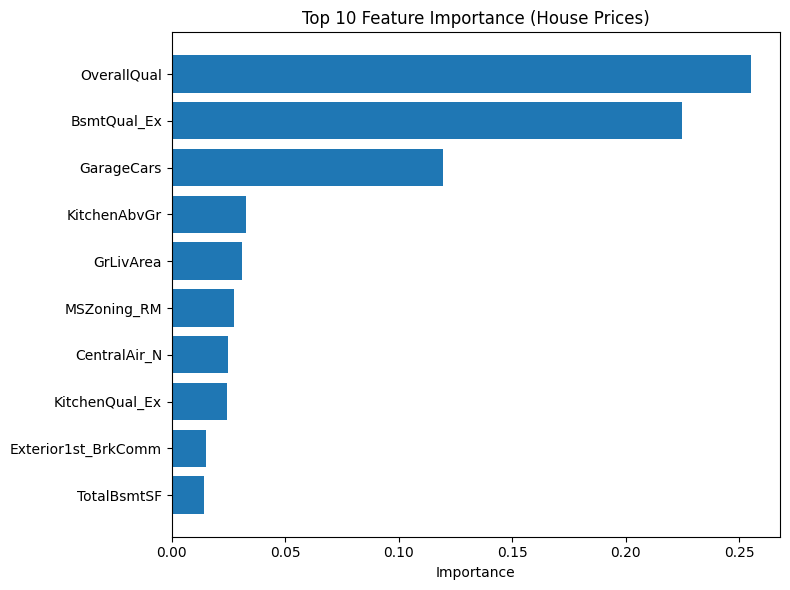

In [151]:
# get feature importance
house_importance = pd.Series(reg_house.feature_importances_, index=X_house.columns)
house_importance = house_importance.sort_values(ascending=False).head(10)

# plot
plt.figure(figsize=(8, 6))
plt.barh(house_importance.index[::-1], house_importance.values[::-1])
plt.title("Top 10 Feature Importance (House Prices)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()